In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import decorate, configure_plot_style, AIBM_COLORS

configure_plot_style()

# Life Expectancy

## WEF data

Now let's see how these results compare to WEF.
Here's the data pulled from the PDF report.

In [3]:
from utils import read_wef_file

wef = read_wef_file("wef_life_expectancy.csv").drop(columns=['diff', 'left', 'right'])
wef.shape

(146, 4)

In [4]:
wef.head()

,country,page_number,score,rank
code,,,,
ALB,Albania,83,1.033,79
DZA,Algeria,85,0.990,144
AGO,Angola,87,1.050,55
ARG,Argentina,89,1.051,51
ARM,Armenia,91,1.060,1


In [5]:
wef.tail()

,country,page_number,score,rank
code,,,,
UZB,Uzbekistan,365,1.036,76
VUT,Vanuatu,367,1.054,45
VNM,Vietnam,369,1.060,1
ZMB,Zambia,371,1.060,1
ZWE,Zimbabwe,373,1.060,1


In [6]:
wef['rank'].value_counts(dropna=False).head()

rank
1      37
79      1
144     1
55      1
51      1
Name: count, dtype: int64

In [7]:
dinged = wef['score'] < 1
dinged.sum()

np.int64(6)

Here's the distribution of WEF scores.

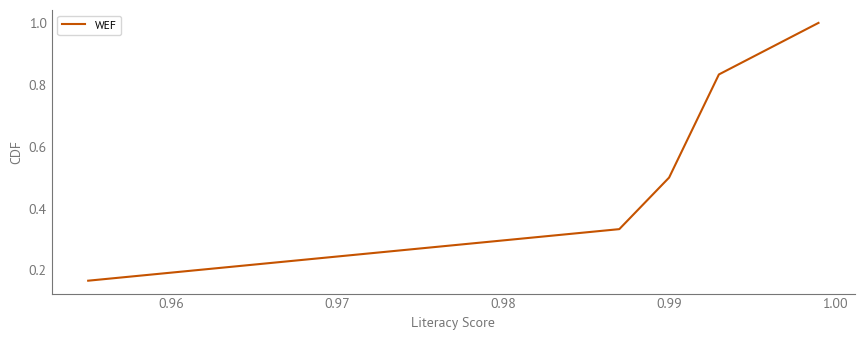

In [8]:
from empiricaldist import Cdf

cdf_dinged = Cdf.from_seq(wef.loc[dinged, 'score'])
cdf_dinged.plot(label='WEF')
decorate(xlabel='Literacy Score', ylabel='CDF')

## Our World In Data



In [9]:
import requests

filename = 'life-expectancy-of-women-vs-life-expectancy-of-men.csv'

In [19]:
owid = pd.read_csv(filename)
owid.columns = ['Entity', 'Code', 'Year',
       'life_expectancy_female',
       'life_expectancy_male',
       'population',
       'region', 'time', 'time.1']

In [20]:
owid.head()

,Entity,Code,Year,life_expectancy_female,life_expectancy_male,population,region,time,time.1
0,Afghanistan,AFG,2023,67.536,64.467,41454709,Asia,2023,2023
1,Albania,ALB,2023,81.446,77.728,2811615,Europe,2023,2023
2,Algeria,DZA,2023,77.696,74.895,46164169,Africa,2023,2023
3,American Samoa,ASM,2023,75.838,70.202,47499,Oceania,2023,2023
4,Andorra,AND,2023,86.107,82.100,80825,Europe,2023,2023


In [21]:
owid['ratio'] = owid['life_expectancy_female'] / owid['life_expectancy_male']
owid.sort_values(by='ratio', ascending=False).head(20)

,Entity,Code,Year,life_expectancy_female,life_expectancy_male,population,region,time,time.1,ratio
221,Ukraine,UKR,2023,80.198,66.900,37732781,Europe,2023,2023,1.198774
162,Palestine,PSE,2023,71.502,59.691,5409153,Asia,2023,2023,1.197869
174,Russia,RUS,2023,79.037,67.256,145440454,Europe,2023,2023,1.175167
225,United States Virgin Islands,VIR,2023,81.352,70.513,85666,North America,2023,2023,1.153716
77,Georgia,GEO,2023,79.107,69.569,3807436,Asia,2023,2023,1.137101
18,Belarus,BLR,2023,79.065,69.535,9115626,Europe,2023,2023,1.137053
139,Mongolia,MNG,2023,76.430,67.244,3431887,Asia,2023,2023,1.136607
137,Moldova,MDA,2023,75.535,66.568,3067017,Europe,2023,2023,1.134704
231,Vietnam,VNM,2023,79.264,69.877,100352143,Asia,2023,2023,1.134336
121,Lithuania,LTU,2023,80.675,71.216,2854061,Europe,2023,2023,1.132821


In [97]:
owid['score'] = 1 - np.abs(owid['ratio'] - 1)

In [98]:
owid['ratio'].describe()

count    177.000000
mean       0.960370
std        0.156699
min        0.300022
25%        0.979836
50%        1.000000
75%        1.007404
max        1.512420
Name: ratio, dtype: float64

In [99]:
owid['score_truncated'] = np.where(owid['ratio'] > 1, 1, owid['score'])

In [100]:
owid.head(20)

,entity,year,literacy_male,literacy_female,owid_region,ratio,score,score_truncated
code,,,,,,,,
ABW,Aruba,2023,99.00000,99.00000,North America,1.000000,1.000000,1.000000
AFG,Afghanistan,2023,83.40000,44.17171,Asia,0.529637,0.529637,0.529637
AGO,Angola,2023,83.96919,67.42760,Africa,0.803004,0.803004,0.803004
AIA,Anguilla,2023,99.00000,99.00000,North America,1.000000,1.000000,1.000000
ALA,Aland Islands,2023,NaN,NaN,Europe,NaN,NaN,NaN
ALB,Albania,2023,98.58999,99.49000,Europe,1.009129,0.990871,1.000000
AND,Andorra,2023,NaN,NaN,Europe,NaN,NaN,NaN
ANT,Netherlands Antilles,2023,NaN,NaN,North America,NaN,NaN,NaN
ARE,United Arab Emirates,2023,100.00000,100.00000,Asia,1.000000,1.000000,1.000000


In [101]:
owid['score'].describe()

count    177.000000
mean       0.925555
std        0.143390
min        0.300022
25%        0.936170
50%        0.989899
75%        1.000000
max        1.000000
Name: score, dtype: float64

In [102]:
owid['score_truncated'].describe()

count    177.000000
mean       0.942962
std        0.134883
min        0.300022
25%        0.979836
50%        1.000000
75%        1.000000
max        1.000000
Name: score_truncated, dtype: float64

Add the OWID data to WEF

In [103]:
merge_column(wef, owid['score'], 'owid_score')
# merge_column(wef, owid['score_truncated'], 'owid_score_truncated')

Index(['AUS', 'AUT', 'BEL', 'CAN', 'CZE', 'DNK', 'FIN', 'FRA', 'DEU', 'ISL',
       'IRL', 'JPN', 'LUX', 'NLD', 'NZL', 'NOR', 'SVK', 'SWE', 'CHE', 'GBR',
       'USA'],
      dtype='object', name='code')

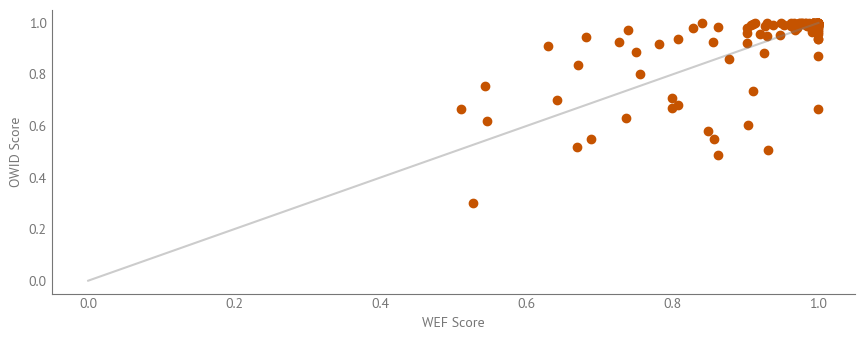

In [104]:
plt.plot([0, 1], [0, 1], color='gray', alpha=0.4)
plt.scatter(wef['score'], wef['owid_score'])
decorate(xlabel='WEF Score', ylabel='OWID Score')

## OECD PIAAC

From https://www.oecd.org/en/about/programmes/piaac.html

>The Programme for the International Assessment of Adult Competencies (PIAAC) is a programme of assessment and analysis of adult skills. The major product of PIAAC is the Survey of Adult Skills, an international computer-based household survey of adults aged 16-65 years. It is designed as 10-yearly cycles.
>
>The Survey measures adults’ proficiency in key information-processing skills - literacy, numeracy and problem solving – which represent skills needed for individuals to participate in society and for economies to prosper. It also gathers information and data on how adults use their skills at home and at work.
>
>The 1st Cycle of the Survey of Adult Skills was conducted over three separate rounds between 2011 and 2018 in 39 countries. During the 1st Cycle, about 245 000 adults were interviewed, representing 1.15 billion people.
>
>The 2nd Cycle of the Survey of Adults Skills has been conducted in 31 countries and economies so far. A first round of data collection took place in 2022-2023 with results released on 10 December 2024.  




I downloaded two tables from https://www.oecd.org/en/publications/do-adults-have-the-skills-they-need-to-thrive-in-a-changing-world_b263dc5d-en/full-report/tables-of-results-for-countries-and-economies_0432d7e4.html#annex-d1e19379-dc605a08b8:

* Table A.2.7 (L): Literacy proficiency, by gender

* Table A.2.8 (L): Literacy proficiency, by gender and age group

Both are sheets in this Excel spreadsheet: https://stat.link/eb8dxq

The first table includes "Percentage of low performers (scoring at Level 1 or below)", which we will use as a replacement for illiteracy.

Here's the description of Level 1:

> Adults at Level 1 are able to locate information on a text page, find a relevant link from a website, and identify relevant text among multiple options when the relevant information is explicitly cued. They can understand the meaning of short texts, as well as the organization of lists or multiple sections within a single page.
>
>The texts at level 1 may be continuous, noncontinuous, or mixed and pertain to printed or digital environments. They typically include a single page with up to a few hundred words and little or no distracting information. Noncontinuous texts may have a list structure (such as a web search engine results page) or include a small number of independent sections, possibly with pictorial illustrations or simple diagrams. Tasks at Level 1 involve simple questions providing some guidance as to what needs to be done and a single processing step. There is a direct, fairly obvious match between the question and target information in the text, although some tasks may require the examination of more than one piece of information.

We'll flip the sense by computing:

`literacy rate = (100 - Percentage of low performers)`

Here's the data.


In [105]:
piaac = pd.read_excel('eb8dxq.xlsx', sheet_name='A.2.7 (L)', skiprows=6, skipfooter=11)

piaac.columns = ['country', 'mean', 'se', 
           'male_mean', 'male_mean_se', 'female_mean', 'female_mean_se',
           'diff', 'diff_se', 
           'unused', 'unused', 'unused', 'unused', 
           'male_percent', 'male_percent_se', 'female_percent', 'female_percent_se', 
           'unused', 'unused']
piaac['country'] = piaac['country'].replace('Poland*', 'Poland')
piaac.head()

,country,mean,se,male_mean,male_mean_se,female_mean,female_mean_se,diff,diff_se,unused,unused,unused,unused,male_percent,male_percent_se,female_percent,female_percent_se,unused,unused
0,Austria,254.369808,0.880442,254.309342,1.451380,254.430673,1.187266,-0.121331,1.983984,0.951235,-2.799169,1.736435,0.106957,29.282004,1.231198,28.620819,1.125002,0.661185,1.777549
1,Canada,270.770314,0.870268,271.017313,1.437290,270.522105,1.139001,0.495207,1.923685,0.796850,0.638806,1.614895,0.692421,19.670112,1.145555,18.873108,0.983209,0.797005,1.585128
2,Chile,217.889950,2.153137,217.680876,3.046819,218.099045,1.813228,-0.418169,2.568732,0.870682,0.458546,1.766441,0.795182,53.238281,2.393751,53.549892,1.859101,-0.311611,2.405293
3,Czechia,260.205637,0.982685,259.479752,1.676722,260.958352,1.230915,-1.478599,2.199785,0.501484,0.795314,1.835662,0.664828,26.072850,1.385492,23.422168,1.051619,2.650682,1.936533
4,Denmark,273.033693,0.811874,271.499922,1.404251,274.600515,1.177973,-3.100594,2.023761,0.125499,1.055020,1.518884,0.487304,19.805036,1.053472,15.903784,0.809196,3.901252,1.441933


In [106]:
piaac_country_to_code = {
    'Austria': 'AUT',
    'Canada': 'CAN',
    'Chile': 'CHL',
    'Czechia': 'CZE',
    'Denmark': 'DNK',
    'Estonia': 'EST',
    'Finland': 'FIN',
    'France': 'FRA',
    'Germany': 'DEU',
    'Hungary': 'HUN',
    'Ireland': 'IRL',
    'Israel': 'ISR',
    'Italy': 'ITA',
    'Japan': 'JPN',
    'Korea': 'KOR',
    'Latvia': 'LVA',
    'Lithuania': 'LTU',
    'Netherlands': 'NLD',
    'New Zealand': 'NZL',
    'Norway': 'NOR',
    'Poland': 'POL',
    'Portugal': 'PRT',
    'Slovak Republic': 'SVK',
    'Spain': 'ESP',
    'Sweden': 'SWE',
    'Switzerland': 'CHE',
    'United States': 'USA'
}



In [107]:
piaac.index = piaac['country'].map(piaac_country_to_code)
piaac.index.name = 'code'
piaac.head()

,country,mean,se,male_mean,male_mean_se,female_mean,female_mean_se,diff,diff_se,unused,unused,unused,unused,male_percent,male_percent_se,female_percent,female_percent_se,unused,unused
code,,,,,,,,,,,,,,,,,,,
AUT,Austria,254.369808,0.880442,254.309342,1.451380,254.430673,1.187266,-0.121331,1.983984,0.951235,-2.799169,1.736435,0.106957,29.282004,1.231198,28.620819,1.125002,0.661185,1.777549
CAN,Canada,270.770314,0.870268,271.017313,1.437290,270.522105,1.139001,0.495207,1.923685,0.796850,0.638806,1.614895,0.692421,19.670112,1.145555,18.873108,0.983209,0.797005,1.585128
CHL,Chile,217.889950,2.153137,217.680876,3.046819,218.099045,1.813228,-0.418169,2.568732,0.870682,0.458546,1.766441,0.795182,53.238281,2.393751,53.549892,1.859101,-0.311611,2.405293
CZE,Czechia,260.205637,0.982685,259.479752,1.676722,260.958352,1.230915,-1.478599,2.199785,0.501484,0.795314,1.835662,0.664828,26.072850,1.385492,23.422168,1.051619,2.650682,1.936533
DNK,Denmark,273.033693,0.811874,271.499922,1.404251,274.600515,1.177973,-3.100594,2.023761,0.125499,1.055020,1.518884,0.487304,19.805036,1.053472,15.903784,0.809196,3.901252,1.441933


Here's the ratio intended to be comparable to the WEF equity scores, except that it's symmetric.

In [108]:
piaac['ratio'] = (100 - piaac['female_percent']) / (100 - piaac['male_percent'])
piaac['ratio'].describe()

count    27.000000
mean      1.041883
std       0.032982
min       0.973661
25%       1.018114
50%       1.045394
75%       1.062122
max       1.099257
Name: ratio, dtype: float64

In [109]:
piaac['score'] = 1 - np.abs(piaac['ratio'] - 1)
piaac['score'].describe()

count    27.000000
mean      0.955317
std       0.028915
min       0.900743
25%       0.937878
50%       0.954606
75%       0.977354
max       0.995735
Name: score, dtype: float64

In [110]:
piaac['score_truncated'] = np.where(piaac['ratio'] > 1, 1, piaac['score'])
piaac['score_truncated'].describe()

count    27.000000
mean      0.998600
std       0.005219
min       0.973661
25%       1.000000
50%       1.000000
75%       1.000000
max       1.000000
Name: score_truncated, dtype: float64

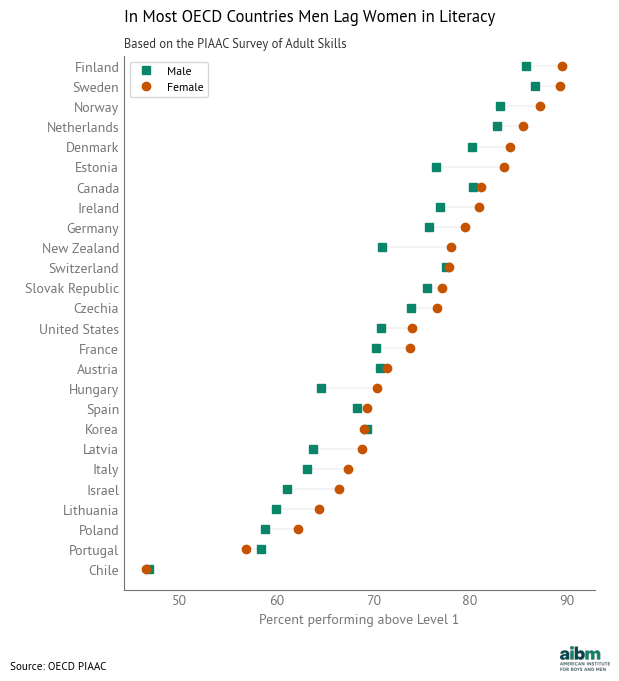

In [111]:
from utils import add_title, add_subtext, add_logo

piaac_sorted = piaac.sort_values(by='female_percent')
country = piaac_sorted['country']
male = 100 - piaac_sorted['male_percent']
female = 100 - piaac_sorted['female_percent']

fig, ax = plt.subplots(figsize=(6, 6))
plt.hlines(country, male, female, color=AIBM_COLORS['light_gray'])
plt.plot(male, country, 's', color=AIBM_COLORS['green'], label='Male')
plt.plot(female, country, 'o', color=AIBM_COLORS['orange'], label='Female')
ax.invert_yaxis()

decorate(xlabel='Percent performing above Level 1', ylim=[len(piaac), 0.5])
add_title("In Most OECD Countries Men Lag Women in Literacy",
          "Based on the PIAAC Survey of Adult Skills", y=1.01)
add_subtext("Source: OECD PIAAC", y=-0.05)
logo = add_logo(location=(1.0, -0.05))

### Merge PIACC into WEF



In [112]:
merge_column(wef, piaac['ratio'], "piaac_ratio")
merge_column(wef, piaac['score'], "piaac_score")

Index(['ALB', 'DZA', 'AGO', 'ARG', 'ARM', 'AUS', 'AZE', 'BHR', 'BGD', 'BRB',
       ...
       'UKR', 'ARE', 'GBR', 'TZA', 'URY', 'UZB', 'VUT', 'VNM', 'ZMB', 'ZWE'],
      dtype='object', name='code', length=119)

There are only a few countries where we have an UNESCO score and a PIACC score. Some countries that got perfect scores from WEF get downgraded based on PIACC, but not by much.

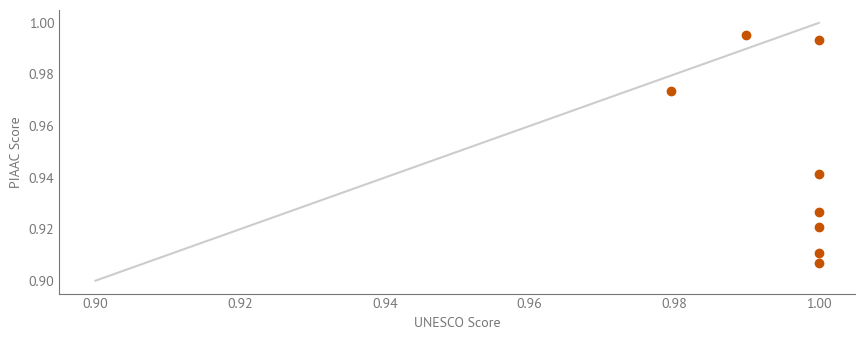

In [113]:
plt.plot([0.9, 1], [0.9, 1], color='gray', alpha=0.4)
plt.scatter(wef['unesco_score'], wef['piaac_score'])
decorate(xlabel='UNESCO Score', ylabel='PIAAC Score')

In [114]:
wef.dropna(subset=['unesco_score', 'piaac_score'])

,country,page_number,score,rank,unesco_ratio,unesco_score,owid_score,piaac_ratio,piaac_score
code,,,,,,,,,
CHL,Chile,141,0.999,56.0,1.000000,1.000000,0.995964,0.993336,0.993336
EST,Estonia,171,1.000,1.0,1.000000,1.000000,1.000000,1.093016,0.906984
HUN,Hungary,201,1.000,1.0,1.000000,1.000000,1.000000,1.089204,0.910796
LVA,Latvia,233,1.000,1.0,1.000000,1.000000,1.000000,1.079061,0.920939
LTU,Lithuania,241,1.000,1.0,1.000000,1.000000,1.000000,1.073272,0.926728
POL,Poland,299,1.000,1.0,1.000000,1.000000,1.000000,1.058585,0.941415
PRT,Portugal,301,0.981,84.0,0.979592,0.979592,1.000000,0.973661,0.973661
KOR,South Korea,325,0.992,72.0,0.989899,0.989899,1.000000,0.995206,0.995206


## Bring it together

Now let's bring in the data from UNESCO and PIACC.

In [115]:
wef['ratio'] = np.nan
wef['ratio'] = wef['ratio'].where(wef['unesco_ratio'].isna(), wef['unesco_ratio'])
wef['ratio'] = wef['ratio'].where(wef['piaac_ratio'].isna(), wef['piaac_ratio'])
wef['ratio'].describe()

count    93.000000
mean      0.942197
std       0.136531
min       0.488889
25%       0.902174
50%       0.990000
75%       1.015911
max       1.250000
Name: ratio, dtype: float64

In [116]:
wef['revised_score'] = wef['score'].where(wef['unesco_score'].isna(), 
                                          wef['unesco_score'])

wef['revised_score'] = wef['revised_score'].where(wef['piaac_score'].isna(), 
                                                  wef['piaac_score'])
wef['revised_score'].describe()

count    146.000000
mean       0.920544
std        0.115860
min        0.488889
25%        0.906158
50%        0.969223
75%        0.994905
max        1.000000
Name: revised_score, dtype: float64

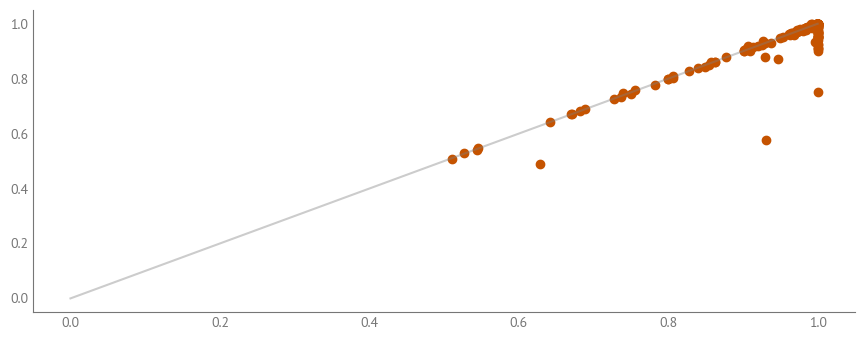

In [117]:
plt.plot([0, 1], [0, 1], color='gray', alpha=0.4)
plt.scatter(wef['score'], wef['revised_score'])
decorate()

In [118]:
wef['diff_score'] = np.abs(wef['revised_score'] - wef['score'])

In [119]:
wef.sort_values(by='diff_score', ascending=False).head(20)

,country,page_number,score,rank,unesco_ratio,unesco_score,owid_score,piaac_ratio,piaac_score,ratio,revised_score,diff_score
code,,,,,,,,,,,,
CIV,Côte D'Ivoire,153,0.931,103.0,0.576923,0.576923,0.506424,NaN,NaN,0.576923,0.576923,0.354077
LSO,Lesotho,237,1.000,1.0,1.250000,0.750000,0.935942,NaN,NaN,1.250000,0.750000,0.250000
BEN,Benin,111,0.629,140.0,0.488889,0.488889,0.910697,NaN,NaN,0.488889,0.488889,0.140111
NZL,New Zealand,275,1.000,1.0,NaN,NaN,NaN,1.099257,0.900743,1.099257,0.900743,0.099257
EST,Estonia,171,1.000,1.0,1.000000,1.000000,1.000000,1.093016,0.906984,1.093016,0.906984,0.093016
HUN,Hungary,201,1.000,1.0,1.000000,1.000000,1.000000,1.089204,0.910796,1.089204,0.910796,0.089204
ISR,Israel,213,1.000,1.0,NaN,NaN,0.989899,1.088358,0.911642,1.088358,0.911642,0.088358
LVA,Latvia,233,1.000,1.0,1.000000,1.000000,1.000000,1.079061,0.920939,1.079061,0.920939,0.079061
RWA,Rwanda,307,0.947,101.0,0.873239,0.873239,0.954545,NaN,NaN,0.873239,0.873239,0.073761


In [120]:
wef.loc['AUS']

country          Australia
page_number             93
score                  1.0
rank                   1.0
unesco_ratio           NaN
unesco_score           NaN
owid_score             NaN
piaac_ratio            NaN
piaac_score            NaN
ratio                  NaN
revised_score          1.0
diff_score             0.0
Name: AUS, dtype: object

## Revised Scores

Here's the distribution of revised scores.

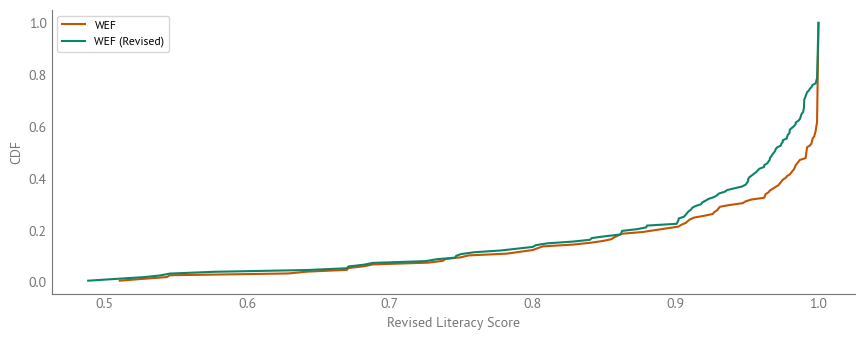

In [121]:
cdf_score = Cdf.from_seq(wef['score'])
cdf_score.plot(label='WEF')
cdf_revised = Cdf.from_seq(wef['revised_score'])
cdf_revised.plot(label='WEF (Revised)')
decorate(xlabel='Revised Literacy Score', ylabel='CDF')

In [122]:
wef_sorted = wef.sort_values(by='score', ascending=False)

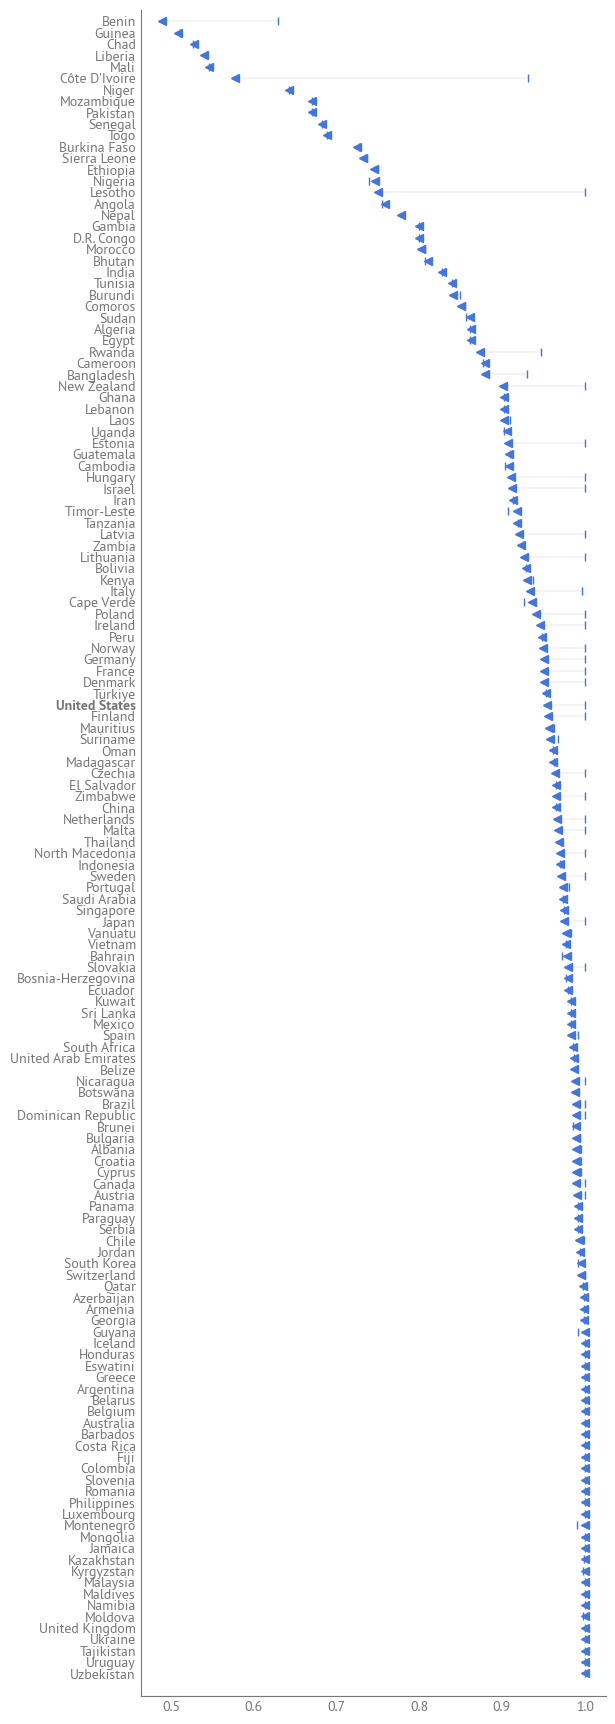

In [123]:
from utils import plot_revised_scores

plot_revised_scores(wef.sort_values('revised_score'))

## Export the results

In [124]:
from utils import make_rank_table

table = make_rank_table(wef)
table.head()

,country,ratio,rank,revised_rank,score,revised_score
code,,,,,,
ALB,Albania,0.989899,65.0,47.0,0.996,0.989899
DZA,Algeria,0.862069,119.0,119.0,0.862,0.862069
AGO,Angola,0.759036,130.0,130.0,0.755,0.759036
ARG,Argentina,NaN,1.0,1.0,1.000,1.000000
ARM,Armenia,NaN,58.0,32.0,0.999,0.999000


In [125]:
table.to_csv("wef_literacy_rate_table.csv")
table.shape

(146, 6)

In [126]:
from utils import make_weight_table

make_weight_table(table, 'primary')

original            revised          
             std   inv std      std   inv std
primary   0.1117  0.089526  0.11586  0.086311

In [127]:
from utils import oecd_codes

# TODO: For the OECD countries with no PIAAC data, set to NaN
# and fill with regression on the other data

missing = set(oecd_codes).difference(piaac.index)
table.loc[list(missing)]

,country,ratio,rank,revised_rank,score,revised_score
code,,,,,,
CRI,Costa Rica,1.0,1.0,1.0,1.000,1.000
SVN,Slovenia,1.0,1.0,1.0,1.000,1.000
BEL,Belgium,NaN,1.0,1.0,1.000,1.000
TUR,Türkiye,NaN,99.0,87.0,0.953,0.953
GBR,United Kingdom,NaN,1.0,1.0,1.000,1.000
MEX,Mexico,NaN,81.0,58.0,0.984,0.984
AUS,Australia,NaN,1.0,1.0,1.000,1.000
LUX,Luxembourg,NaN,1.0,1.0,1.000,1.000
GRC,Greece,NaN,1.0,1.0,1.000,1.000


In [128]:
df_oecd = wef.loc[oecd_codes].sort_values(by='revised_score')

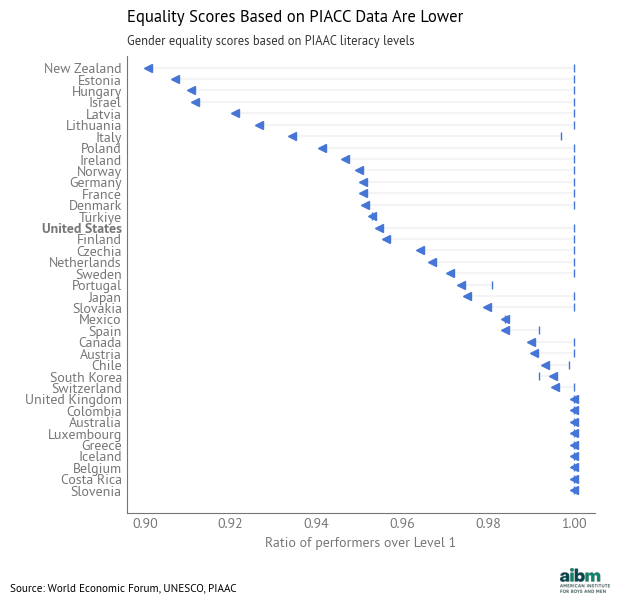

In [131]:
plot_revised_scores(df_oecd)

add_title("Equality Scores Based on PIACC Data Are Lower", 
    "Gender equality scores based on PIAAC literacy levels", y=1.02
)
decorate(xlabel='Ratio of performers over Level 1')
add_subtext("Source: World Economic Forum, UNESCO, PIAAC", y=-0.05)
logo = add_logo(location=(1.0, -0.05))


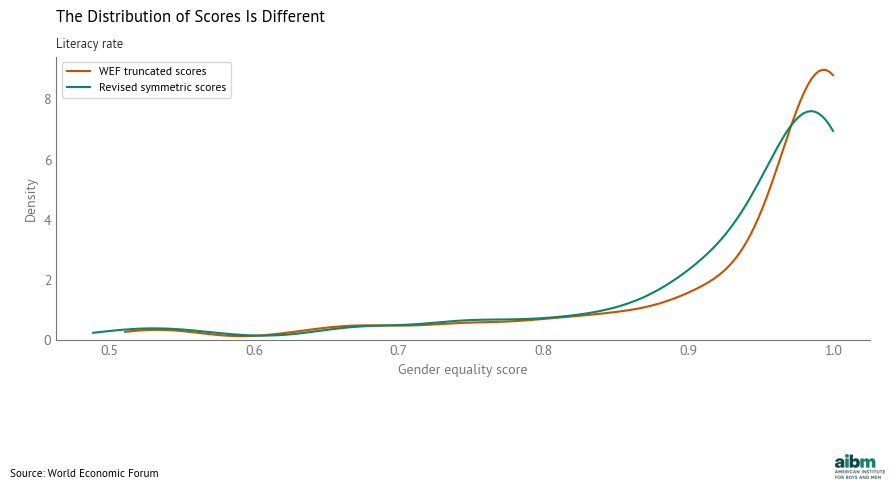

In [130]:
import seaborn as sns

options = dict(cut=0, bw_adjust=0.7)

sns.kdeplot(wef['score'], label='WEF truncated scores', **options)
sns.kdeplot(wef['revised_score'], label='Revised symmetric scores', **options)

decorate(xlabel='Gender equality score')

add_title("The Distribution of Scores Is Different",
          "Literacy rate")
add_subtext("Source: World Economic Forum", y=-0.25)
logo = add_logo(location=(1.0, -0.25))
None